# Stage 8 — Model training

_Pipeline stage 8 of `docs/PIPELINE_DESIGN.md`. Uses the canonical `channel_heads` package + on-disk artifacts; heavy rebuilds run via the `channel-heads` CLI (see each stage's command)._

## Training the CNN + combined XGBoost (per regime)

Two models per regime: **OutletCNN** (5-class patch -> 4-D embedding, Taiwan held
out) and the **combined XGBoost** (5 features + 4 embeddings = 9, split by
`GroupShuffleSplit` on `basin__outlet` so no outlet leaks across train/test). Train:
`python -m channel_heads train-cnn-regime` then `train-combined-xgb-regime`.

In [1]:
%matplotlib inline
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import channel_heads as ch
from channel_heads.io.paths import PROJECT_ROOT, RESULTS_DIR, EXAMPLE_DEMS
ROOT     = PROJECT_ROOT
MODELS   = ROOT / 'models'
MARS_OUT = ROOT / 'data/Mars/model_outputs'
MARS_IN  = ROOT / 'data/Mars/model_inputs'
REGIMES_ = ['regA', 'regB', 'regC']
# Frozen model features (5 dimensionless) + operating thresholds (Stage 9).
MODEL_FEATURES = ['orientation_diff_deg','headhead_dist_norm','apex_angle_deg',
                  'strahler_order_diff','proximity_profile_norm']
OP_THR = {'regA': 0.756326, 'regB': 0.779264, 'regC': 0.759369}
print('channel_heads', ch.__version__, '| root', ROOT)


channel_heads 0.1.0 | root /Users/guypi/Projects/channel-heads


### CNN convergence (per-regime loss curves)

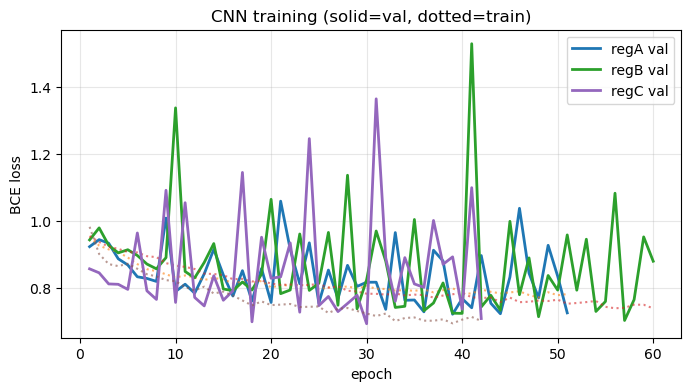

In [2]:
fig, ax = plt.subplots(figsize=(8, 4))
for r in REGIMES_:
    h = MODELS / f'cnn_outlet_{r}_history.csv'
    if h.exists():
        hist = pd.read_csv(h)
        ax.plot(hist.epoch, hist.val_loss, label=f'{r} val', lw=2)
        ax.plot(hist.epoch, hist.train_loss, ls=':', alpha=0.6)
ax.set_xlabel('epoch'); ax.set_ylabel('BCE loss'); ax.set_title('CNN training (solid=val, dotted=train)')
ax.legend(); ax.grid(alpha=0.3); plt.show()

### Does the CNN embedding separate the classes?

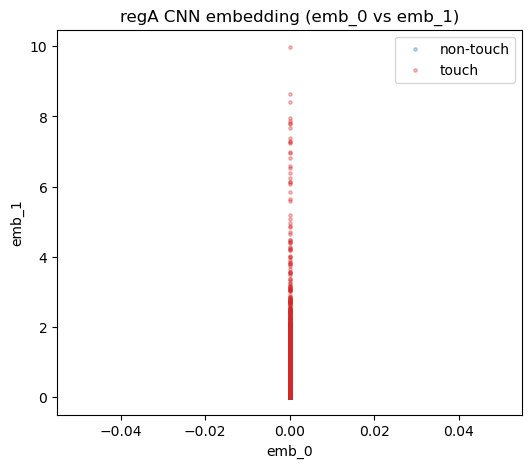

In [3]:
d = pd.read_csv(RESULTS_DIR / 'master_dataset_regA_with_emb.csv')
fig, ax = plt.subplots(figsize=(6, 5))
for lbl, col, name in [(0, '#1f77b4', 'non-touch'), (1, '#d62728', 'touch')]:
    s = d[d.y == lbl].sample(min(1500, int((d.y==lbl).sum())), random_state=0)
    ax.scatter(s.emb_0, s.emb_1, s=6, alpha=0.3, c=col, label=name)
ax.set_xlabel('emb_0'); ax.set_ylabel('emb_1'); ax.set_title('regA CNN embedding (emb_0 vs emb_1)')
ax.legend(); plt.show()

### Model-comparison table (geom-only vs geom+CNN per regime)

In [4]:
p = MODELS / 'ALL_MODELS_METRICS.csv'
pd.read_csv(p) if p.exists() else 'train models first'

,model,n_feat,roc_auc,pr_auc,thr,P,R,F1,Acc
0,baseline geom_only,5,0.7474,0.7055,0.5953,0.6533,0.5034,0.5687,0.6855
1,baseline geom+cnn_emb,9,0.9103,0.8784,0.8420,0.9068,0.5000,0.6446,0.7729
2,baseline geom+cnn_logit,6,0.9110,0.8788,0.8331,0.9176,0.5342,0.6753,0.7884
3,regA geom_only,5,0.7652,0.6256,0.5803,0.5560,0.5000,0.5265,0.7435
4,regA geom+cnn_emb,9,0.8827,0.7557,0.7563,0.7537,0.5023,0.6028,0.8112
5,regB geom_only,5,0.7109,0.5725,0.5355,0.4913,0.5000,0.4956,0.6774
6,regB geom+cnn_emb,9,0.8814,0.7748,0.7793,0.7788,0.5039,0.6119,0.7974
7,regC geom_only,5,0.7956,0.6470,0.5897,0.5962,0.5029,0.5456,0.7818
8,regC geom+cnn_emb,9,0.8841,0.7644,0.7594,0.7921,0.5007,0.6136,0.8357


The CNN embedding lifts ROC-AUC by ~0.09 to 0.17 over geometry alone per regime —
the patch shape carries real, complementary signal. Deep dives:
`notebooks/training/{02_train_classifier,04_cnn_embeddings,05_cnn_quick_eval}.ipynb`.